In [2]:
import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
file_path = r"C:\Users\MahRukh\Downloads\AChE_clean_experimental.csv"

data = pd.read_csv(file_path)

print("Dataset shape:", data.shape)
print("Total compounds:", len(data))

Dataset shape: (6870, 3)
Total compounds: 6870


In [4]:
required_columns = ["Ligand SMILES", "Activity"]

for col in required_columns:
    assert col in data.columns, f"Missing column: {col}"

print("Activity distribution:")
print(data["Activity"].value_counts(dropna=False))

assert data["Activity"].isin(["Inactive", "Active"]).all()

print("\nDataset validation passed.")

Activity distribution:
Activity
Inactive    5360
Active      1510
Name: count, dtype: int64

Dataset validation passed.


In [5]:
data["Mol"] = data["Ligand SMILES"].apply(Chem.MolFromSmiles)

invalid = data["Mol"].isna().sum()

print("Invalid SMILES:", invalid)

data = data.dropna(subset=["Mol"]).reset_index(drop=True)

print("Valid compounds:", len(data))

Invalid SMILES: 1
Valid compounds: 6869


In [7]:
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def get_morgan_fp(mol):
    fp = morgan_generator.GetFingerprint(mol)
    return np.array(fp)

X = np.array([
    get_morgan_fp(mol)
    for mol in data["Mol"]
])

print("Fingerprint shape:", X.shape)

Fingerprint shape: (6869, 2048)


In [8]:
y = data["Activity"].map({
    "Inactive": 0,
    "Active": 1
}).values

print("Inactive:", np.sum(y == 0))
print("Active:", np.sum(y == 1))

Inactive: 5359
Active: 1510


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", len(X_train))
print("Test set:", len(X_test))

Training set: 5495
Test set: 1374


In [19]:
smote_random = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote_random.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print("Inactive:", np.sum(y_train == 0))
print("Active:", np.sum(y_train == 1))

print("\nAfter SMOTE:")
print("Inactive:", np.sum(y_train_smote == 0))
print("Active:", np.sum(y_train_smote == 1))

print("\nTest set remains untouched.")

Before SMOTE:
Inactive: 4287
Active: 1208

After SMOTE:
Inactive: 4287
Active: 4287

Test set remains untouched.


In [20]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    )
}

print("Five models defined.")

Five models defined.


In [21]:
comparison_results = []

for name, model in models.items():

    print(f"Training {name}...")

    start = time.time()

    model.fit(X_train_smote, y_train_smote)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    elapsed = time.time() - start

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "MCC": matthews_corrcoef(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Time_sec": elapsed
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\nMODEL COMPARISON")
print("=" * 80)
print(comparison_df.round(4).to_string(index=False))

Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training SVM...
Training Logistic Regression...

MODEL COMPARISON
              Model  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  PR-AUC  Time_sec
      Random Forest    0.8996     0.7628  0.7881 0.7752 0.7108   0.9296  0.7979    9.0585
        Extra Trees    0.8967     0.7667  0.7616 0.7641 0.6980   0.9186  0.7869   18.1946
                SVM    0.8930     0.7575  0.7550 0.7562 0.6877   0.9140  0.7928  267.8747
            XGBoost    0.8770     0.7034  0.7616 0.7313 0.6526   0.9056  0.7790    8.8480
Logistic Regression    0.8552     0.6635  0.6921 0.6775 0.5844   0.8973  0.7385    1.7180


In [22]:
comparison_path = r"C:\Users\MahRukh\Downloads\AChE_model_comparison.csv"

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("Model comparison saved:")
print(comparison_path)


Model comparison saved:
C:\Users\MahRukh\Downloads\AChE_model_comparison.csv


In [23]:
data["Scaffold"] = [
    MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )
    for mol in data["Mol"]
]

print("Unique scaffolds:", data["Scaffold"].nunique())

Unique scaffolds: 2725


In [24]:
scaffold_groups = data.groupby("Scaffold").indices

scaffold_sets = sorted(
    scaffold_groups.values(),
    key=len,
    reverse=True
)

target_train = int(0.80 * len(data))

scaf_train_indices = []
scaf_test_indices = []
train_count = 0

for group in scaffold_sets:

    if train_count < target_train:
        scaf_train_indices.extend(group)
        train_count += len(group)
    else:
        scaf_test_indices.extend(group)

scaf_train_indices = np.array(scaf_train_indices)
scaf_test_indices = np.array(scaf_test_indices)

X_scaf_train = X[scaf_train_indices]
y_scaf_train = y[scaf_train_indices]

X_scaf_test = X[scaf_test_indices]
y_scaf_test = y[scaf_test_indices]

print("Scaffold training set:", len(X_scaf_train))
print("Scaffold test set:", len(X_scaf_test))

Scaffold training set: 5495
Scaffold test set: 1374


In [25]:
train_scaffolds = set(
    data.iloc[scaf_train_indices]["Scaffold"]
)

test_scaffolds = set(
    data.iloc[scaf_test_indices]["Scaffold"]
)

scaffold_overlap = train_scaffolds.intersection(
    test_scaffolds
)

print("Scaffold overlap:", len(scaffold_overlap))

assert len(scaffold_overlap) == 0

print("✓ No scaffold leakage.")

Scaffold overlap: 0
✓ No scaffold leakage.


In [26]:
train_smiles = set(
    data.iloc[scaf_train_indices]["Ligand SMILES"]
)

test_smiles = set(
    data.iloc[scaf_test_indices]["Ligand SMILES"]
)

smiles_overlap = train_smiles.intersection(
    test_smiles
)

print(
    "Exact duplicate SMILES between train/test:",
    len(smiles_overlap)
)

assert len(smiles_overlap) == 0

print("✓ No exact duplicate SMILES leakage.")

Exact duplicate SMILES between train/test: 0
✓ No exact duplicate SMILES leakage.


In [27]:
smote_scaffold = SMOTE(random_state=42)

X_scaf_train_smote, y_scaf_train_smote = (
    smote_scaffold.fit_resample(
        X_scaf_train,
        y_scaf_train
    )
)

print("Before SMOTE:")
print("Inactive:", np.sum(y_scaf_train == 0))
print("Active:", np.sum(y_scaf_train == 1))

print("\nAfter SMOTE:")
print("Inactive:", np.sum(y_scaf_train_smote == 0))
print("Active:", np.sum(y_scaf_train_smote == 1))

print("\n✓ Scaffold test set was NOT subjected to SMOTE.")

Before SMOTE:
Inactive: 4322
Active: 1173

After SMOTE:
Inactive: 4322
Active: 4322

✓ Scaffold test set was NOT subjected to SMOTE.


In [28]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start = time.time()

rf_grid.fit(
    X_scaf_train_smote,
    y_scaf_train_smote
)

print("\nTuning completed.")
print("Time:", round(time.time() - start, 2), "seconds")

print("\nBest parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:",
      round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Tuning completed.
Time: 959.11 seconds

Best parameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV ROC-AUC: 0.9852


In [29]:
best_rf = rf_grid.best_estimator_

print("Best Random Forest:")
print(best_rf)

Best Random Forest:
RandomForestClassifier(max_features='log2', n_estimators=300, n_jobs=-1,
                       random_state=42)


In [30]:
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_prob = cross_val_predict(
    best_rf,
    X_scaf_train_smote,
    y_scaf_train_smote,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF predictions generated:", len(oof_prob))

OOF predictions generated: 8644


In [31]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    pred = (oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_scaf_train_smote, pred
        ),
        "Precision": precision_score(
            y_scaf_train_smote, pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_scaf_train_smote, pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_scaf_train_smote, pred,
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_scaf_train_smote, pred
        )
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold = threshold_df.loc[
    threshold_df["MCC"].idxmax(),
    "Threshold"
]

print(threshold_df.round(4).to_string(index=False))

print("\nSelected threshold:", best_threshold)

 Threshold  Accuracy  Precision  Recall     F1    MCC
      0.20    0.8688     0.7963  0.9912 0.8831 0.7608
      0.25    0.8919     0.8291  0.9875 0.9014 0.7986
      0.30    0.9077     0.8544  0.9829 0.9141 0.8247
      0.35    0.9195     0.8754  0.9783 0.9240 0.8448
      0.40    0.9280     0.8936  0.9718 0.9311 0.8594
      0.45    0.9351     0.9080  0.9683 0.9372 0.8721
      0.50    0.9383     0.9178  0.9630 0.9398 0.8777
      0.55    0.9407     0.9275  0.9560 0.9416 0.8817
      0.60    0.9424     0.9361  0.9496 0.9428 0.8849
      0.65    0.9417     0.9444  0.9387 0.9415 0.8834
      0.70    0.9409     0.9536  0.9269 0.9400 0.8821
      0.75    0.9383     0.9622  0.9125 0.9367 0.8778
      0.80    0.9316     0.9719  0.8889 0.9286 0.8664

Selected threshold: 0.5999999999999999


In [32]:
final_rf = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_scaf_train_smote,
    y_scaf_train_smote
)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


In [33]:
final_prob = final_rf.predict_proba(
    X_scaf_test
)[:, 1]

final_pred = (
    final_prob >= best_threshold
).astype(int)

accuracy = accuracy_score(
    y_scaf_test,
    final_pred
)

precision = precision_score(
    y_scaf_test,
    final_pred,
    zero_division=0
)

recall = recall_score(
    y_scaf_test,
    final_pred,
    zero_division=0
)

f1 = f1_score(
    y_scaf_test,
    final_pred,
    zero_division=0
)

mcc = matthews_corrcoef(
    y_scaf_test,
    final_pred
)

roc_auc = roc_auc_score(
    y_scaf_test,
    final_prob
)

pr_auc = average_precision_score(
    y_scaf_test,
    final_prob
)

final_results = pd.DataFrame([{
    "Model": "Random Forest",
    "Validation": "Scaffold Test",
    "Threshold": best_threshold,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "MCC": mcc,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

print(final_results.round(4).to_string(index=False))

        Model    Validation  Threshold  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  PR-AUC
Random Forest Scaffold Test        0.6    0.8501     0.7382  0.6024 0.6634 0.5731   0.8523  0.6712


In [34]:
cm = confusion_matrix(
    y_scaf_test,
    final_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_scaf_test,
        final_pred,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Confusion Matrix:
[[965  72]
 [134 203]]

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.8781    0.9306    0.9036      1037
      Active     0.7382    0.6024    0.6634       337

    accuracy                         0.8501      1374
   macro avg     0.8081    0.7665    0.7835      1374
weighted avg     0.8438    0.8501    0.8447      1374



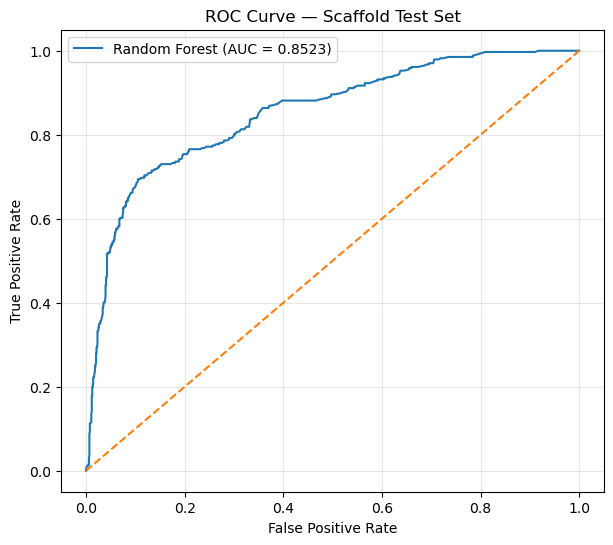

In [35]:
fpr, tpr, _ = roc_curve(
    y_scaf_test,
    final_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Scaffold Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

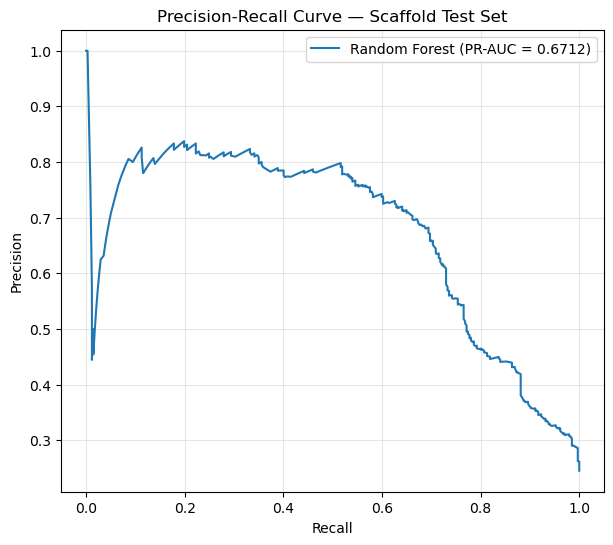

In [36]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_scaf_test,
    final_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Random Forest (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Scaffold Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    "Fingerprint_Bit": np.arange(X.shape[1]),
    "Importance": final_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 fingerprint features:")
print(
    feature_importance.head(20).to_string(index=False)
)

Top 20 fingerprint features:
 Fingerprint_Bit  Importance
             712    0.006505
            1048    0.006411
             875    0.006313
            1098    0.005960
             389    0.005812
            1143    0.005205
              80    0.005023
             592    0.004873
             381    0.004855
             310    0.004741
            1214    0.004662
            1152    0.004564
             667    0.004349
            1199    0.004318
            1416    0.004311
            1088    0.004210
             650    0.004140
             832    0.004111
            1948    0.004005
            1917    0.003934


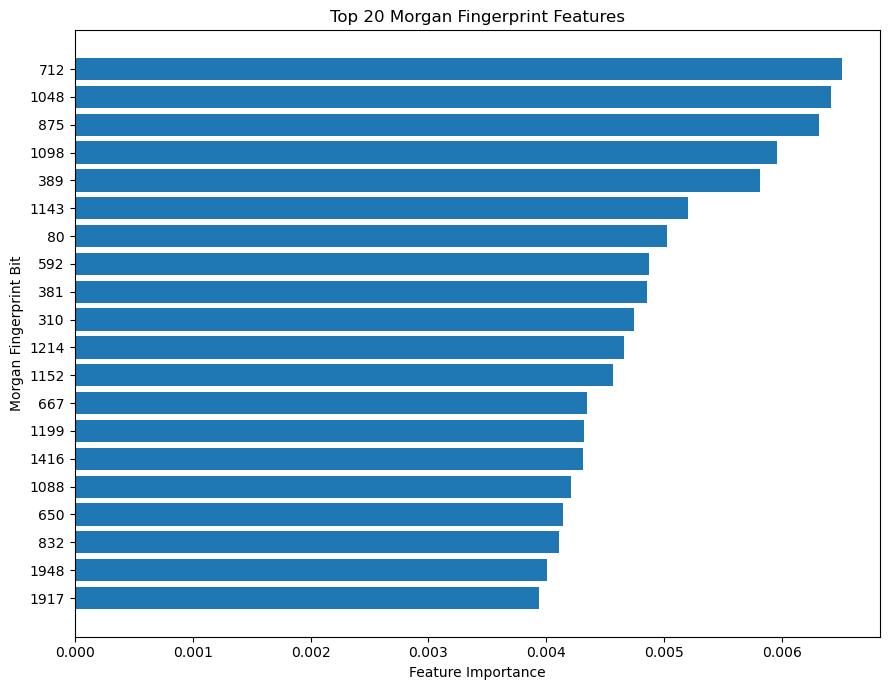

In [38]:
top20 = feature_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top20["Fingerprint_Bit"].astype(str),
    top20["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Morgan Fingerprint Bit")
plt.title("Top 20 Morgan Fingerprint Features")

plt.tight_layout()
plt.show()

In [39]:
model_path = r"C:\Users\MahRukh\Downloads\AChE_Final_RF_model.pkl"

joblib.dump(
    final_rf,
    model_path
)

print("Final model saved successfully:")
print(model_path)

Final model saved successfully:
C:\Users\MahRukh\Downloads\AChE_Final_RF_model.pkl


In [40]:
results_path = r"C:\Users\MahRukh\Downloads\AChE_final_scaffold_results.csv"

final_results.to_csv(
    results_path,
    index=False
)

print("Final results saved:")
print(results_path)

Final results saved:
C:\Users\MahRukh\Downloads\AChE_final_scaffold_results.csv
